# Cicero planner intent behavior measurement

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 16
## CICERO planner-intent → outward-behavior measurement

Notebook 15 established a successful mechanistic positive control: the released full CICERO agent locally produced a completed native `BRMResult` from `run_bilateral_search_with_conditional_evs`, with agent/blueprint/population policies and a subsequent generated message.

Notebook 16 moves from **one successful capture** to a **small measured episode bank**. It keeps the frozen CICERO checkout and legacy runtime unchanged, extends the runtime instrumentation, and records enough planner→message / planner→order transitions to determine whether CICERO's explicit strategic-search state is a usable mechanistic intent reference.

### Primary measurement questions

1. When a final order is submitted, how much probability did the immediately available CICERO search policy assign to that exact order set?
2. Does the search-refined agent policy predict the submitted order better than the corresponding blueprint policy?
3. For generated bilateral messages, can we pair each message to the correct preceding bilateral planner result using **sender + recipient + phase**, rather than simply choosing the closest search event?
4. Are the resulting planner/message/order records clean enough to support the next exact-input observer experiment?

### Claim boundary

This notebook is **not** an activation-vs-text H1 estimate and makes **no causal steering claim**. The internal CICERO planner is an architectural positive-control signal, not an activation reader. The raw `pydipcc.Game` object is retained only for identity/audit hashing and is **not** declared to be a matched text-only observation. A later observer stage must capture the exact dialogue-model input boundary before making a privileged-access comparison.

### Frozen input

The default upstream Notebook 15 run is pinned explicitly to:

`20260815T140016Z`

It can be overridden only with `LR_NB15_RUN_ID` for an intentionally selected alternative run.


In [1]:
from __future__ import annotations

import csv
import hashlib
import importlib.util
import json
import math
import os
import queue
import shlex
import shutil
import signal
import subprocess
import sys
import threading
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

required = {
    "numpy": "numpy<2",
    "pandas": "pandas>=2,<3",
    "matplotlib": "matplotlib>=3.8,<4",
    "tqdm": "tqdm>=4.66",
}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display

NOTEBOOK_BUILD = "latent-reservations-notebook16-cicero-planner-intent-behavior-v1"
print("=" * 100)
print("NOTEBOOK BUILD:", NOTEBOOK_BUILD)
print("CICERO planner-intent -> outward-behavior measurement")
print("=" * 100)


NOTEBOOK BUILD: latent-reservations-notebook16-cicero-planner-intent-behavior-v1
CICERO planner-intent -> outward-behavior measurement


## 1. Paths, frozen provenance, and run isolation

The full CICERO process still runs in Notebook 14/15's isolated Python 3.7 + PyTorch 1.7.1 environment. This notebook kernel only orchestrates the process and analyzes JSON artifacts.


In [2]:
PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
CICERO_REPO = PROJECT_ROOT / "vendor" / "diplomacy_cicero"
CICERO_COMMIT = "e85afeddb34f5b7c1ea0827203b425a0f7e68ead"

LEGACY_ENV = PROJECT_ROOT / ".venvs" / "cicero_full_agent_py37_source_v5"
LEGACY_PYTHON = LEGACY_ENV / "bin" / "python"
PYTHON_BASE = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "cpython-3.7.17"
OPENSSL_PREFIX = PROJECT_ROOT / "vendor" / "cicero_runtime_v5" / "openssl-1.1.1w"
COMPARE_CONFIG = CICERO_REPO / "conf" / "c01_ag_cmp" / "cmp.prototxt"
CICERO_AGENT_INCLUDE = "agents/cicero.prototxt"

NB15_RUN_ID = os.environ.get("LR_NB15_RUN_ID", "20260815T140016Z")
NB15_RUN_DIR = (
    PROJECT_ROOT
    / "notebook_outputs"
    / "15_cicero_planner_capture_mechanistic_positive_control"
    / NB15_RUN_ID
)
NB15_SUMMARY_PATH = NB15_RUN_DIR / "results" / "tables" / "result_summary.json"

NOTEBOOK_SLUG = "16_cicero_planner_intent_behavior_measurement"
RUN_ID = os.environ.get("LR_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_DIR = BASE / RUN_ID
MANIFEST_DIR = RUN_DIR / "manifests"
DATA_DIR = RUN_DIR / "data"
RUNTIME_DIR = DATA_DIR / "runtime"
CAPTURE_DIR = DATA_DIR / "planner_behavior_events"
INSTRUMENT_DIR = DATA_DIR / "instrumentation"
RESULT_DIR = RUN_DIR / "results"
TABLE_DIR = RESULT_DIR / "tables"
FIGURE_DIR = RESULT_DIR / "figures"

for p in [MANIFEST_DIR, RUNTIME_DIR, CAPTURE_DIR, INSTRUMENT_DIR, TABLE_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)
BASE.mkdir(parents=True, exist_ok=True)

TARGET_MESSAGE_RESULTS = int(os.environ.get("LR_NB16_TARGET_MESSAGE_RESULTS", "6"))
TARGET_ORDER_RESULTS = int(os.environ.get("LR_NB16_TARGET_ORDER_RESULTS", "3"))
CAPTURE_TIMEOUT_SECONDS = int(os.environ.get("LR_NB16_CAPTURE_TIMEOUT_SECONDS", "3600"))
STRICT_READINESS = os.environ.get("LR_NB16_STRICT_READINESS", "1").strip().lower() not in {"0", "false", "no"}
EXTRA_COMPARE_OVERRIDES = shlex.split(os.environ.get("LR_NB16_COMPARE_OVERRIDES", ""))

(BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(json.dumps({
    "run_id": RUN_ID,
    "run_dir": str(RUN_DIR),
    "nb15_run_id": NB15_RUN_ID,
    "target_message_results": TARGET_MESSAGE_RESULTS,
    "target_order_results": TARGET_ORDER_RESULTS,
    "capture_timeout_seconds": CAPTURE_TIMEOUT_SECONDS,
    "extra_compare_overrides": EXTRA_COMPARE_OVERRIDES,
}, indent=2))


{
  "run_id": "20260815T143203Z",
  "run_dir": "/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z",
  "nb15_run_id": "20260815T140016Z",
  "target_message_results": 6,
  "target_order_results": 3,
  "capture_timeout_seconds": 3600,
  "extra_compare_overrides": []
}


## 2. Validate the accepted Notebook 15 handoff

Do not silently use the newest directory. The default handoff is the known successful Notebook 15 run, and its readiness flags must still be green.


In [3]:
def capture_command(command, *, cwd=None, env=None, timeout=None):
    completed = subprocess.run(
        [str(x) for x in command],
        cwd=str(cwd) if cwd is not None else None,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=timeout,
    )
    return {"returncode": completed.returncode, "output": completed.stdout}

required_paths = [
    CICERO_REPO,
    LEGACY_PYTHON,
    PYTHON_BASE,
    OPENSSL_PREFIX,
    COMPARE_CONFIG,
    NB15_SUMMARY_PATH,
]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing Notebook 16 prerequisites:\n" + "\n".join(missing_paths))

actual_commit = capture_command(["git", "rev-parse", "HEAD"], cwd=CICERO_REPO)
if actual_commit["returncode"] != 0:
    raise RuntimeError(actual_commit["output"])
actual_commit_value = actual_commit["output"].strip()
if actual_commit_value != CICERO_COMMIT:
    raise RuntimeError(f"Frozen CICERO commit mismatch: {actual_commit_value} != {CICERO_COMMIT}")

nb15_summary = json.loads(NB15_SUMMARY_PATH.read_text())
nb15_readiness = nb15_summary.get("readiness", {})
required_nb15 = {
    "completed_native_planner_result_captured": True,
    "planner_policy_payload_present": True,
    "outward_event_paired": True,
    "capture_error_events_absent": True,
    "ready_for_following_measurement_stage": True,
}
for key, expected in required_nb15.items():
    if nb15_readiness.get(key) is not expected:
        raise RuntimeError(f"Notebook 15 handoff failed readiness field {key}: {nb15_readiness.get(key)!r}")

if nb15_summary.get("planner_method") != "run_bilateral_search_with_conditional_evs":
    raise RuntimeError(
        "Notebook 16 expects the accepted Notebook 15 runtime path to include "
        "run_bilateral_search_with_conditional_evs. Got: " + repr(nb15_summary.get("planner_method"))
    )

print(json.dumps({
    "cicero_commit": actual_commit_value,
    "nb15_run": str(NB15_RUN_DIR),
    "nb15_planner_method": nb15_summary.get("planner_method"),
    "nb15_planner_result_type": nb15_summary.get("planner_result_type"),
    "nb15_outward_event_type": nb15_summary.get("outward_event_type"),
    "nb15_ready": nb15_readiness.get("ready_for_following_measurement_stage"),
}, indent=2))


{
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "nb15_run": "/workspace/latent-reservations/notebook_outputs/15_cicero_planner_capture_mechanistic_positive_control/20260815T140016Z",
  "nb15_planner_method": "run_bilateral_search_with_conditional_evs",
  "nb15_planner_result_type": "fairdiplomacy.agents.bqre1p_agent.BRMResult",
  "nb15_outward_event_type": "generate_message_result",
  "nb15_ready": true
}


## 3. Recreate the validated legacy runtime environment

The environment route is inherited from Notebook 15. We verify the exact Python/PyTorch/CUDA/Postman/`pydipcc` stack again before launching the measurement process.


In [4]:
stack_markers = sorted(LEGACY_ENV.glob(".latent_reservations_cicero_stack_v5_*"))
if not stack_markers:
    raise RuntimeError("Notebook 14/15 legacy stack marker is missing.")

torch_route_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import json,pathlib,torch; "
        "root=pathlib.Path(torch.__file__).resolve().parent; "
        "print(json.dumps({'version':torch.__version__,'cuda':torch.version.cuda,"
        "'cuda_available':torch.cuda.is_available(),'root':str(root),'lib':str(root/'lib')}))"
    ),
], cwd=CICERO_REPO)
if torch_route_probe["returncode"] != 0:
    raise RuntimeError(torch_route_probe["output"])
torch_route = json.loads(torch_route_probe["output"].strip().splitlines()[-1])
if not torch_route["version"].startswith("1.7.1"):
    raise RuntimeError("Expected PyTorch 1.7.1 in CICERO legacy runtime: " + json.dumps(torch_route))

legacy_runtime_env = os.environ.copy()
legacy_runtime_env.pop("PYTHONHOME", None)
legacy_runtime_env.pop("PYTHONPATH", None)
legacy_runtime_env["PYTHONNOUSERSITE"] = "1"
legacy_runtime_env["VIRTUAL_ENV"] = str(LEGACY_ENV)
legacy_runtime_env["PATH"] = os.pathsep.join([str(LEGACY_ENV / "bin"), os.environ.get("PATH", "")])

runtime_library_dirs = [Path(torch_route["lib"]), LEGACY_ENV / "lib", PYTHON_BASE / "lib"]
for candidate in [OPENSSL_PREFIX / "lib", OPENSSL_PREFIX / "lib64", Path("/usr/local/cuda/lib64")]:
    if candidate.exists():
        runtime_library_dirs.append(candidate)
legacy_runtime_env["LD_LIBRARY_PATH"] = os.pathsep.join(str(p) for p in runtime_library_dirs if p.exists())

preflight_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import json,sys,torch,postman; "
        "from fairdiplomacy import pydipcc; "
        "from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent,BRMResult; "
        "print(json.dumps({'python':sys.executable,'torch':torch.__version__,"
        "'cuda_build':torch.version.cuda,'cuda_available':torch.cuda.is_available(),"
        "'postman':postman.__file__,'pydipcc':pydipcc.__file__,"
        "'agent':str(BQRE1PAgent),'result':str(BRMResult)}))"
    ),
], cwd=CICERO_REPO, env=legacy_runtime_env)
(RUNTIME_DIR / "preflight_probe.txt").write_text(preflight_probe["output"])
if preflight_probe["returncode"] != 0:
    raise RuntimeError("Notebook 16 legacy runtime preflight failed:\n" + preflight_probe["output"])
preflight = json.loads(preflight_probe["output"].strip().splitlines()[-1])
print(json.dumps(preflight, indent=2))


{
  "python": "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
  "torch": "1.7.1+cu110",
  "cuda_build": "11.0",
  "cuda_available": true,
  "postman": "/workspace/latent-reservations/vendor/diplomacy_cicero/thirdparty/github/fairinternal/postman/postman/python/postman/__init__.py",
  "pydipcc": "/workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-37m-x86_64-linux-gnu.so",
  "agent": "<class 'fairdiplomacy.agents.bqre1p_agent.BQRE1PAgent'>",
  "result": "<class 'fairdiplomacy.agents.bqre1p_agent.BRMResult'>"
}


## 4. Measurement instrumentation

The Notebook 16 hook is deliberately narrower than Notebook 15's exploratory serializer:

- it records compact, directly comparable policy distributions;
- each wrapped call gets an explicit `call_id`;
- bilateral searches retain `agent_power`, `other_power`, and phase;
- `get_orders` snapshots any cached search result before/after the call, so order-time analysis does not depend on a fresh `run_search` call;
- outward messages retain the actual output recipient;
- the game is hashed for identity/audit, but the raw engine serialization is not treated as a text-observer input.


In [5]:
SITE_CUSTOMIZE = INSTRUMENT_DIR / "sitecustomize.py"

INSTRUMENTATION_SOURCE = r'''import hashlib
import inspect
import json
import os
import time
import traceback
from pathlib import Path

_CAPTURE_DIR_TEXT = os.environ.get("LR_CICERO_CAPTURE_DIR", "").strip()

if _CAPTURE_DIR_TEXT:
    import numpy as np
    import torch
    from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent

    _CAPTURE_DIR = Path(_CAPTURE_DIR_TEXT)
    _CAPTURE_DIR.mkdir(parents=True, exist_ok=True)
    _CAPTURE_PATH = _CAPTURE_DIR / (str(os.getpid()) + ".jsonl")
    _SCHEMA_VERSION = 1
    _SEQ = 0
    _CALL_SEQ = 0
    _MAX_DEPTH = 12
    _MAX_SEQUENCE = 1024
    _MAX_TENSOR_ELEMENTS = 512
    _MAX_POLICY_ACTIONS = 512

    def _next_call_id(prefix):
        global _CALL_SEQ
        _CALL_SEQ += 1
        return prefix + "-" + str(os.getpid()) + "-" + str(_CALL_SEQ)

    def _phase_name(game):
        try:
            value = getattr(game, "current_short_phase", None)
            if callable(value):
                value = value()
            return None if value is None else str(value)
        except Exception:
            return None

    def _json_key(value):
        if isinstance(value, str):
            return value
        if isinstance(value, tuple):
            return " | ".join(str(item) for item in value)
        return repr(value)

    def _safe(value, depth=0):
        if depth > _MAX_DEPTH:
            return {"__type__": type(value).__module__ + "." + type(value).__name__, "__repr__": repr(value)[:500]}
        if value is None or isinstance(value, (bool, int, float, str)):
            return value
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, torch.Tensor):
            tensor = value.detach().cpu()
            payload = {"__type__": "torch.Tensor", "shape": list(tensor.shape), "dtype": str(tensor.dtype), "numel": int(tensor.numel())}
            if tensor.numel() <= _MAX_TENSOR_ELEMENTS:
                payload["values"] = tensor.tolist()
            return payload
        if isinstance(value, np.ndarray):
            payload = {"__type__": "numpy.ndarray", "shape": list(value.shape), "dtype": str(value.dtype), "size": int(value.size)}
            if value.size <= _MAX_TENSOR_ELEMENTS:
                payload["values"] = value.tolist()
            return payload
        if isinstance(value, dict):
            items = list(value.items())
            out = {}
            for key, item in items[:_MAX_SEQUENCE]:
                out[_json_key(key)] = _safe(item, depth + 1)
            if len(items) > _MAX_SEQUENCE:
                out["__truncated_items__"] = len(items) - _MAX_SEQUENCE
            return out
        if isinstance(value, (list, tuple, set)):
            seq = list(value)
            out = [_safe(item, depth + 1) for item in seq[:_MAX_SEQUENCE]]
            if len(seq) > _MAX_SEQUENCE:
                out.append({"__truncated_items__": len(seq) - _MAX_SEQUENCE})
            return out
        if hasattr(value, "__dict__"):
            selected = {}
            tokens = ("belief", "ptype", "player_type", "policy", "plausible", "utility", "value")
            for name, item in value.__dict__.items():
                if any(token in name.lower() for token in tokens):
                    selected[name] = _safe(item, depth + 1)
            return {"__type__": type(value).__module__ + "." + type(value).__name__, "__selected_state__": selected, "__repr__": repr(value)[:500]}
        return {"__type__": type(value).__module__ + "." + type(value).__name__, "__repr__": repr(value)[:500]}

    def _game_context(game):
        payload = {"phase": _phase_name(game)}
        try:
            year = getattr(game, "current_year", None)
            if callable(year):
                year = year()
            if year is not None:
                payload["year"] = int(year)
        except Exception:
            pass
        try:
            state = game.get_state()
            payload["state"] = _safe(state)
        except Exception as exc:
            payload["state_error"] = repr(exc)
        try:
            raw = game.to_json()
            if not isinstance(raw, str):
                raw = json.dumps(raw, sort_keys=True)
            payload["game_json_sha256"] = hashlib.sha256(raw.encode("utf-8", "replace")).hexdigest()
            payload["game_json_bytes"] = len(raw.encode("utf-8", "replace"))
        except Exception as exc:
            payload["game_json_error"] = repr(exc)
        return payload

    def _emit(event, payload):
        global _SEQ
        _SEQ += 1
        record = {
            "schema_version": _SCHEMA_VERSION,
            "event": event,
            "sequence": _SEQ,
            "time_unix": time.time(),
            "pid": os.getpid(),
            "ppid": os.getppid(),
            "payload": _safe(payload),
        }
        encoded = json.dumps(record, separators=(",", ":"), sort_keys=True)
        with _CAPTURE_PATH.open("a", encoding="utf-8") as handle:
            handle.write(encoded)
            handle.write("\n")
            handle.flush()
            os.fsync(handle.fileno())

    def _action_orders(action):
        if action is None:
            return []
        if isinstance(action, (tuple, list)):
            return [str(x) for x in action]
        if isinstance(action, str):
            if " | " in action:
                return [part.strip() for part in action.split(" | ") if part.strip()]
            return [action]
        return [str(action)]

    def _policy_payload(policy):
        if not isinstance(policy, dict):
            return {"__error__": "policy_not_dict", "value": _safe(policy)}
        powers = {}
        for power, dist in policy.items():
            if not isinstance(dist, dict):
                powers[str(power)] = {"__error__": "distribution_not_dict", "value": _safe(dist)}
                continue
            rows = []
            total = 0.0
            for action, probability in dist.items():
                try:
                    prob = float(probability)
                except Exception:
                    continue
                total += prob
                rows.append({
                    "orders": _action_orders(action),
                    "probability": prob,
                })
            rows.sort(key=lambda row: -row["probability"])
            truncated = max(0, len(rows) - _MAX_POLICY_ACTIONS)
            powers[str(power)] = {
                "action_count": len(rows),
                "probability_sum": total,
                "actions": rows[:_MAX_POLICY_ACTIONS],
                "truncated_actions": truncated,
            }
        return powers

    def _planner_result_payload(result):
        payload = {
            "type": type(result).__module__ + "." + type(result).__name__,
            "policies": {},
            "beliefs": _safe(getattr(result, "beliefs", None)),
        }
        for name in ["get_agent_policy", "get_bp_policy", "get_population_policy"]:
            method = getattr(result, name, None)
            if method is None or not callable(method):
                payload["policies"][name] = {"__missing__": True}
                continue
            try:
                payload["policies"][name] = _policy_payload(method())
            except Exception as exc:
                payload["policies"][name] = {"__error__": repr(exc), "__traceback__": traceback.format_exc()}
        avg_utility = getattr(result, "avg_utility", None)
        if avg_utility is not None and callable(avg_utility):
            utility = {}
            for power in ["AUSTRIA", "ENGLAND", "FRANCE", "GERMANY", "ITALY", "RUSSIA", "TURKEY"]:
                try:
                    utility[power] = float(avg_utility(power))
                except Exception:
                    pass
            payload["avg_utility"] = utility
        return payload

    def _extract_cached_search_result(agent_state, game):
        if agent_state is None:
            return None
        phase = _phase_name(game) if game is not None else None
        candidates = []
        method = getattr(agent_state, "get_last_search_result", None)
        if method is not None and callable(method):
            for route, args in [("get_last_search_result(game)", (game,)), ("get_last_search_result(phase)", (phase,)), ("get_last_search_result()", ())]:
                try:
                    value = method(*args)
                except Exception:
                    continue
                if hasattr(value, "get_agent_policy"):
                    candidates.append((3, route, value))
                    break
        for attr_name in ["_last_search_result", "last_search_result"]:
            try:
                value = getattr(agent_state, attr_name, None)
            except Exception:
                value = None
            if value is None:
                continue
            if hasattr(value, "get_agent_policy"):
                candidates.append((2, attr_name, value))
            elif isinstance(value, dict):
                for key, item in value.items():
                    if hasattr(item, "get_agent_policy"):
                        score = 1 if phase and phase in str(key) else 0
                        candidates.append((score, attr_name + "[" + str(key) + "]", item))
        if not candidates:
            return None
        candidates.sort(key=lambda row: row[0], reverse=True)
        _, route, result = candidates[0]
        return {"route": route, "result": _planner_result_payload(result)}

    def _bound_inputs(original, instance, args, kwargs):
        payload = {}
        raw = {}
        try:
            signature = inspect.signature(original)
            bound = signature.bind_partial(instance, *args, **kwargs)
            raw = dict(bound.arguments)
            raw.pop("self", None)
        except Exception as exc:
            payload["binding_error"] = repr(exc)
            return payload, raw
        game = raw.get("game")
        if game is not None:
            payload["game"] = _game_context(game)
        for name in ["power", "agent_power", "other_power", "recipient", "timestamp", "early_exit_for_power"]:
            if name in raw:
                payload[name] = _safe(raw[name])
        if "conditional_evs" in raw:
            try:
                payload["conditional_evs_len"] = len(raw["conditional_evs"])
            except Exception:
                payload["conditional_evs_len"] = None
        return payload, raw

    def _patch_planner_method(method_name):
        original = getattr(BQRE1PAgent, method_name, None)
        if original is None or not callable(original):
            _emit("instrumentation_method_missing", {"method": method_name})
            return
        if getattr(original, "_lr_nb16_wrapped", False):
            return

        def wrapper(self, *args, **kwargs):
            call_id = _next_call_id(method_name)
            inputs, raw_inputs = _bound_inputs(original, self, args, kwargs)
            _emit(method_name + "_begin", {"call_id": call_id, "planner_method": method_name, "inputs": inputs})
            started = time.monotonic()
            try:
                result = original(self, *args, **kwargs)
            except BaseException as exc:
                _emit(method_name + "_error", {
                    "call_id": call_id,
                    "planner_method": method_name,
                    "elapsed_seconds": time.monotonic() - started,
                    "error": repr(exc),
                    "traceback": traceback.format_exc(),
                })
                raise
            _emit(method_name + "_result", {
                "call_id": call_id,
                "planner_method": method_name,
                "elapsed_seconds": time.monotonic() - started,
                "inputs": inputs,
                "result": _planner_result_payload(result),
            })
            return result

        wrapper.__name__ = "_lr_nb16_" + method_name
        wrapper._lr_nb16_wrapped = True
        setattr(BQRE1PAgent, method_name, wrapper)

    def _patch_outward_method(name):
        original = getattr(BQRE1PAgent, name, None)
        if original is None or not callable(original):
            _emit("instrumentation_method_missing", {"method": name})
            return
        if getattr(original, "_lr_nb16_wrapped", False):
            return

        def wrapper(self, *args, **kwargs):
            call_id = _next_call_id(name)
            inputs, raw_inputs = _bound_inputs(original, self, args, kwargs)
            game = raw_inputs.get("game")
            phase = _phase_name(game) if game is not None else None
            state = raw_inputs.get("state")
            cached_before = _extract_cached_search_result(state, game) if name == "get_orders" else None
            started = time.monotonic()
            try:
                result = original(self, *args, **kwargs)
            except BaseException as exc:
                _emit(name + "_error", {
                    "call_id": call_id,
                    "elapsed_seconds": time.monotonic() - started,
                    "error": repr(exc),
                    "traceback": traceback.format_exc(),
                    "inputs": inputs,
                })
                raise
            cached_after = _extract_cached_search_result(state, game) if name == "get_orders" else None
            if name == "get_orders":
                output = {"orders": _action_orders(result)}
            else:
                output = _safe(result)
            _emit(name + "_result", {
                "call_id": call_id,
                "elapsed_seconds": time.monotonic() - started,
                "inputs": inputs,
                "output": output,
                "cached_search_result_before": cached_before,
                "cached_search_result_after": cached_after,
            })
            return result

        wrapper.__name__ = "_lr_nb16_" + name
        wrapper._lr_nb16_wrapped = True
        setattr(BQRE1PAgent, name, wrapper)

    _patch_planner_method("run_search")
    _patch_planner_method("run_bilateral_search_with_conditional_evs")
    _patch_outward_method("generate_message")
    _patch_outward_method("get_orders")

    _emit("instrumentation_loaded", {
        "schema_version": _SCHEMA_VERSION,
        "agent_class": str(BQRE1PAgent),
        "patched_methods": [
            "run_search",
            "run_bilateral_search_with_conditional_evs",
            "generate_message",
            "get_orders",
        ],
    })
'''

SITE_CUSTOMIZE.write_text(INSTRUMENTATION_SOURCE, encoding="utf-8")
print(SITE_CUSTOMIZE)


/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/data/instrumentation/sitecustomize.py


## 5. Instrumentation probe

Before the long run, prove that Python 3.7 auto-loads the generated `sitecustomize.py` and that the actual `BQRE1PAgent` methods point to Notebook 16 wrappers.


In [6]:
probe_capture_dir = RUNTIME_DIR / "instrumentation_probe_events"
if probe_capture_dir.exists():
    shutil.rmtree(probe_capture_dir)
probe_capture_dir.mkdir(parents=True, exist_ok=True)

instrument_probe_env = legacy_runtime_env.copy()
instrument_probe_env["LR_CICERO_CAPTURE_DIR"] = str(probe_capture_dir)
instrument_probe_env["PYTHONPATH"] = os.pathsep.join([str(INSTRUMENT_DIR), str(CICERO_REPO)])

instrument_probe = capture_command([
    LEGACY_PYTHON,
    "-c",
    (
        "import json,sitecustomize; "
        "from fairdiplomacy.agents.bqre1p_agent import BQRE1PAgent; "
        "print(json.dumps({'sitecustomize':sitecustomize.__file__,"
        "'run_search':BQRE1PAgent.run_search.__name__,"
        "'bilateral':BQRE1PAgent.run_bilateral_search_with_conditional_evs.__name__,"
        "'generate_message':BQRE1PAgent.generate_message.__name__,"
        "'get_orders':BQRE1PAgent.get_orders.__name__}))"
    ),
], cwd=CICERO_REPO, env=instrument_probe_env)
(RUNTIME_DIR / "instrumentation_probe.txt").write_text(instrument_probe["output"])
print(instrument_probe["output"])
if instrument_probe["returncode"] != 0:
    raise RuntimeError("Notebook 16 instrumentation probe failed.")
probe_event_files = list(probe_capture_dir.glob("*.jsonl"))
if not probe_event_files:
    raise RuntimeError("Instrumentation probe loaded but emitted no event file.")
probe_info = json.loads(instrument_probe["output"].strip().splitlines()[-1])
for method_key in ["run_search", "bilateral", "generate_message", "get_orders"]:
    if not str(probe_info.get(method_key, "")).startswith("_lr_nb16_"):
        raise RuntimeError(f"Instrumentation wrapper not installed for {method_key}: {probe_info}")


{"sitecustomize": "/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/data/instrumentation/sitecustomize.py", "run_search": "_lr_nb16_run_search", "bilateral": "_lr_nb16_run_bilateral_search_with_conditional_evs", "generate_message": "_lr_nb16_generate_message", "get_orders": "_lr_nb16_get_orders"}



## 6. Launch the released full agent and collect a measured episode bank

Default stop condition: at least 6 successful generated messages **and** at least 3 successful `get_orders` calls. Because `use_shared_agent=1` may produce several power-order calls close together, the final bank can be larger than the target.

The process is intentionally interrupted after the measurement target is reached; a nonzero return code after that interrupt is not, by itself, a runtime failure.


In [7]:
def load_capture_events():
    events = []
    for path in sorted(CAPTURE_DIR.glob("*.jsonl")):
        with path.open("r", encoding="utf-8", errors="replace") as handle:
            for line_number, line in enumerate(handle, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    event = json.loads(line)
                except json.JSONDecodeError:
                    continue
                event["_capture_file"] = str(path)
                event["_capture_line"] = line_number
                events.append(event)
    events.sort(key=lambda row: (
        float(row.get("time_unix", 0.0)),
        int(row.get("pid", 0)),
        int(row.get("sequence", row.get("_capture_line", 0))),
    ))
    return events

for path in CAPTURE_DIR.glob("*.jsonl"):
    path.unlink()

FULL_AGENT_LOG = RUNTIME_DIR / "full_agent_measurement.log"
compare_command = [
    str(LEGACY_PYTHON),
    "run.py",
    "--adhoc",
    "--cfg",
    str(COMPARE_CONFIG.relative_to(CICERO_REPO)),
    f"Iagent_one={CICERO_AGENT_INCLUDE}",
    "use_shared_agent=1",
    "power_one=TURKEY",
    *EXTRA_COMPARE_OVERRIDES,
]

process_env = legacy_runtime_env.copy()
process_env["PYTHONUNBUFFERED"] = "1"
process_env["LR_CICERO_CAPTURE_DIR"] = str(CAPTURE_DIR)
process_env["PYTHONPATH"] = os.pathsep.join([str(INSTRUMENT_DIR), str(CICERO_REPO)])

process = subprocess.Popen(
    compare_command,
    cwd=CICERO_REPO,
    env=process_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    start_new_session=True,
)

line_queue = queue.Queue()
def reader_thread():
    assert process.stdout is not None
    for line in process.stdout:
        line_queue.put(line)
    line_queue.put(None)

thread = threading.Thread(target=reader_thread, daemon=True)
thread.start()

capture_complete = False
process_exited = False
started = time.monotonic()
last_display = started
last_runtime_sample = 0.0
runtime_samples = []
final_counts = {}

with FULL_AGENT_LOG.open("w", encoding="utf-8") as log_handle:
    progress = tqdm(desc="Collect CICERO planner/behavior episodes", unit="log line", dynamic_ncols=False)
    while True:
        try:
            item = line_queue.get(timeout=1.0)
        except queue.Empty:
            item = "__NO_LINE__"

        if item is None:
            process_exited = True
            break
        if item != "__NO_LINE__":
            log_handle.write(item)
            log_handle.flush()
            progress.update(1)

        events_now = load_capture_events()
        counts = Counter(str(e.get("event")) for e in events_now)
        final_counts = dict(counts)
        message_n = counts.get("generate_message_result", 0)
        order_n = counts.get("get_orders_result", 0)
        error_n = sum(v for k, v in counts.items() if k.endswith("_error"))

        now = time.monotonic()
        if now - last_display >= 10:
            progress.set_postfix_str(
                f"messages={message_n}/{TARGET_MESSAGE_RESULTS} orders={order_n}/{TARGET_ORDER_RESULTS} errors={error_n}"
            )
            progress.refresh()
            last_display = now

        if message_n >= TARGET_MESSAGE_RESULTS and order_n >= TARGET_ORDER_RESULTS:
            capture_complete = True
            break

        if now - last_runtime_sample >= 15:
            sample = capture_command([
                "nvidia-smi",
                "--query-compute-apps=pid,process_name,used_memory",
                "--format=csv,noheader,nounits",
            ])
            runtime_samples.append({
                "timestamp_utc": datetime.now(timezone.utc).isoformat(),
                "output": sample["output"],
            })
            last_runtime_sample = now

        if process.poll() is not None:
            process_exited = True
            break
        if now - started > CAPTURE_TIMEOUT_SECONDS:
            break
    progress.close()

if process.poll() is None:
    try:
        os.killpg(process.pid, signal.SIGINT)
        process.wait(timeout=30)
    except Exception:
        try:
            os.killpg(process.pid, signal.SIGTERM)
            process.wait(timeout=15)
        except Exception:
            os.killpg(process.pid, signal.SIGKILL)
            process.wait()

(RUNTIME_DIR / "gpu_runtime_samples.json").write_text(json.dumps(runtime_samples, indent=2))
launch_result = {
    "command": compare_command,
    "capture_complete": capture_complete,
    "process_exited_before_capture": bool(process_exited and not capture_complete),
    "returncode_after_stop": process.returncode,
    "event_counts_at_stop": final_counts,
    "event_files": [str(p) for p in sorted(CAPTURE_DIR.glob("*.jsonl"))],
    "log_path": str(FULL_AGENT_LOG),
}
(TABLE_DIR / "launch_result.json").write_text(json.dumps(launch_result, indent=2))
print(json.dumps(launch_result, indent=2))

if not capture_complete:
    raise RuntimeError(
        "Notebook 16 capture target was not reached. "
        f"Observed counts: {final_counts}. Inspect {FULL_AGENT_LOG} and {CAPTURE_DIR}. "
        "You may intentionally raise LR_NB16_CAPTURE_TIMEOUT_SECONDS or lower a target, but do not reinterpret a partial run as complete."
    )


Collect CICERO planner/behavior episodes: 0log line [00:00, ?log line/s]

{
  "command": [
    "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
    "run.py",
    "--adhoc",
    "--cfg",
    "conf/c01_ag_cmp/cmp.prototxt",
    "Iagent_one=agents/cicero.prototxt",
    "use_shared_agent=1",
    "power_one=TURKEY"
  ],
  "capture_complete": true,
  "process_exited_before_capture": false,
  "returncode_after_stop": 1,
  "event_counts_at_stop": {
    "instrumentation_loaded": 1,
    "run_bilateral_search_with_conditional_evs_begin": 1722,
    "run_bilateral_search_with_conditional_evs_result": 1722,
    "generate_message_result": 139,
    "get_orders_result": 3
  },
  "event_files": [
    "/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/data/planner_behavior_events/206556.jsonl"
  ],
  "log_path": "/workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/data/runtime/full_agent_measurement.log"
}


## 7. Normalize and pair events

Pairing is explicit and audited.

### Message pairing rule

For each `generate_message_result`, use the **actual output sender, recipient, and phase** and select the most recent preceding `run_bilateral_search_with_conditional_evs_result` from the same PID whose `agent_power`, `other_power`, and phase all match. This avoids the Notebook 15 trap where six bilateral planner results occur in rapid sequence before a single message.

### Order pairing rule

Prefer a planner result cached on the `get_orders` state itself. If unavailable, fall back to the most recent preceding `run_search_result` for the same PID, power, and phase. Every fallback is labeled rather than silently treated as equivalent.


In [8]:
events = load_capture_events()
(RUNTIME_DIR / "capture_events_merged.json").write_text(json.dumps(events, indent=2))

PLANNER_RESULT_EVENTS = {
    "run_search_result",
    "run_bilateral_search_with_conditional_evs_result",
}

planner_events = [e for e in events if e.get("event") in PLANNER_RESULT_EVENTS]
message_events = [e for e in events if e.get("event") == "generate_message_result"]
order_events = [e for e in events if e.get("event") == "get_orders_result"]
error_events = [e for e in events if str(e.get("event", "")).endswith("_error")]

print({
    "events": len(events),
    "planner_results": len(planner_events),
    "messages": len(message_events),
    "orders": len(order_events),
    "errors": len(error_events),
    "event_counts": dict(Counter(e.get("event") for e in events)),
})

def event_inputs(event):
    payload = event.get("payload", {})
    return payload.get("inputs", {}) if isinstance(payload, dict) else {}

def input_phase(event):
    game = event_inputs(event).get("game", {})
    return game.get("phase") if isinstance(game, dict) else None

def planner_result_from_event(event):
    payload = event.get("payload", {})
    return payload.get("result") if isinstance(payload, dict) else None

def canonical_orders(orders):
    if orders is None:
        return tuple()
    if isinstance(orders, str):
        parts = [p.strip() for p in orders.split(" | ")] if " | " in orders else [orders.strip()]
    else:
        parts = [str(x).strip() for x in orders]
    return tuple(sorted(p for p in parts if p))

def policy_rows(result_payload, method_name, power):
    if not isinstance(result_payload, dict):
        return []
    policies = result_payload.get("policies", {})
    method_payload = policies.get(method_name, {}) if isinstance(policies, dict) else {}
    power_payload = method_payload.get(str(power), {}) if isinstance(method_payload, dict) else {}
    rows = power_payload.get("actions", []) if isinstance(power_payload, dict) else []
    return rows if isinstance(rows, list) else []

def policy_map(result_payload, method_name, power):
    out = defaultdict(float)
    for row in policy_rows(result_payload, method_name, power):
        if not isinstance(row, dict):
            continue
        try:
            out[canonical_orders(row.get("orders", []))] += float(row.get("probability", 0.0))
        except Exception:
            pass
    return dict(out)

def policy_stats(result_payload, method_name, power):
    pm = policy_map(result_payload, method_name, power)
    if not pm:
        return {
            "action_count": 0,
            "probability_sum": 0.0,
            "top_orders": tuple(),
            "top_probability": np.nan,
            "entropy": np.nan,
        }
    items = sorted(pm.items(), key=lambda kv: -kv[1])
    probs = np.array([max(0.0, float(p)) for _, p in items], dtype=float)
    total = probs.sum()
    norm = probs / total if total > 0 else probs
    entropy = float(-(norm[norm > 0] * np.log(norm[norm > 0])).sum()) if total > 0 else np.nan
    return {
        "action_count": len(items),
        "probability_sum": float(total),
        "top_orders": items[0][0],
        "top_probability": float(items[0][1]),
        "entropy": entropy,
    }

def total_variation(result_payload, method_a, method_b, power):
    a = policy_map(result_payload, method_a, power)
    b = policy_map(result_payload, method_b, power)
    if not a or not b:
        return np.nan
    keys = set(a) | set(b)
    sa = sum(a.values())
    sb = sum(b.values())
    if sa <= 0 or sb <= 0:
        return np.nan
    return 0.5 * sum(abs(a.get(k, 0.0) / sa - b.get(k, 0.0) / sb) for k in keys)

def rank_and_prob(result_payload, method_name, power, actual_orders):
    pm = policy_map(result_payload, method_name, power)
    if not pm:
        return np.nan, np.nan, False
    actual = canonical_orders(actual_orders)
    items = sorted(pm.items(), key=lambda kv: (-kv[1], kv[0]))
    prob = float(pm.get(actual, 0.0))
    rank = next((i + 1 for i, (action, _) in enumerate(items) if action == actual), np.nan)
    return prob, rank, actual in pm

message_rows = []
for msg in message_events:
    payload = msg.get("payload", {})
    output = payload.get("output") if isinstance(payload, dict) else None
    if not isinstance(output, dict):
        continue
    sender = str(output.get("sender") or event_inputs(msg).get("power") or "")
    recipient = str(output.get("recipient") or "")
    phase = str(output.get("phase") or input_phase(msg) or "")
    candidates = []
    for pe in planner_events:
        if pe.get("pid") != msg.get("pid"):
            continue
        if float(pe.get("time_unix", 0)) > float(msg.get("time_unix", 0)):
            continue
        if pe.get("event") != "run_bilateral_search_with_conditional_evs_result":
            continue
        inp = event_inputs(pe)
        if str(inp.get("agent_power") or "") != sender:
            continue
        if str(inp.get("other_power") or "") != recipient:
            continue
        if str(input_phase(pe) or "") != phase:
            continue
        candidates.append(pe)
    paired = max(candidates, key=lambda e: float(e.get("time_unix", 0))) if candidates else None
    result_payload = planner_result_from_event(paired) if paired is not None else None
    agent_stats = policy_stats(result_payload, "get_agent_policy", sender)
    bp_stats = policy_stats(result_payload, "get_bp_policy", sender)
    message_rows.append({
        "message_event_sequence": msg.get("sequence"),
        "pid": msg.get("pid"),
        "phase": phase,
        "sender": sender,
        "recipient": recipient,
        "message": output.get("message"),
        "time_sent": output.get("time_sent"),
        "pairing_mode": "exact_sender_recipient_phase" if paired is not None else "unpaired",
        "planner_event_sequence": paired.get("sequence") if paired else None,
        "planner_call_id": (paired.get("payload") or {}).get("call_id") if paired else None,
        "planner_lag_seconds": (
            float(msg.get("time_unix", 0)) - float(paired.get("time_unix", 0))
            if paired is not None else np.nan
        ),
        "agent_action_count": agent_stats["action_count"],
        "agent_top_orders": " | ".join(agent_stats["top_orders"]),
        "agent_top_probability": agent_stats["top_probability"],
        "agent_entropy": agent_stats["entropy"],
        "bp_top_orders": " | ".join(bp_stats["top_orders"]),
        "bp_top_probability": bp_stats["top_probability"],
        "agent_bp_total_variation": total_variation(result_payload, "get_agent_policy", "get_bp_policy", sender),
    })

order_rows = []
for oe in order_events:
    payload = oe.get("payload", {})
    inp = event_inputs(oe)
    phase = str(input_phase(oe) or "")
    power = str(inp.get("power") or "")
    output = payload.get("output", {}) if isinstance(payload, dict) else {}
    actual_orders = output.get("orders", []) if isinstance(output, dict) else []

    pairing_mode = None
    result_payload = None
    cached_after = payload.get("cached_search_result_after") if isinstance(payload, dict) else None
    cached_before = payload.get("cached_search_result_before") if isinstance(payload, dict) else None
    if isinstance(cached_after, dict) and isinstance(cached_after.get("result"), dict):
        result_payload = cached_after["result"]
        pairing_mode = "get_orders_cached_state_after"
    elif isinstance(cached_before, dict) and isinstance(cached_before.get("result"), dict):
        result_payload = cached_before["result"]
        pairing_mode = "get_orders_cached_state_before"
    else:
        candidates = []
        for pe in planner_events:
            if pe.get("pid") != oe.get("pid"):
                continue
            if float(pe.get("time_unix", 0)) > float(oe.get("time_unix", 0)):
                continue
            if pe.get("event") != "run_search_result":
                continue
            p_inp = event_inputs(pe)
            p_power = str(p_inp.get("agent_power") or "")
            if p_power and p_power != power:
                continue
            if str(input_phase(pe) or "") != phase:
                continue
            candidates.append(pe)
        paired = max(candidates, key=lambda e: float(e.get("time_unix", 0))) if candidates else None
        if paired is not None:
            result_payload = planner_result_from_event(paired)
            pairing_mode = "preceding_run_search_same_phase_power"
        else:
            pairing_mode = "unpaired"

    agent_prob, agent_rank, agent_support = rank_and_prob(result_payload, "get_agent_policy", power, actual_orders)
    bp_prob, bp_rank, bp_support = rank_and_prob(result_payload, "get_bp_policy", power, actual_orders)
    pop_prob, pop_rank, pop_support = rank_and_prob(result_payload, "get_population_policy", power, actual_orders)
    agent_stats = policy_stats(result_payload, "get_agent_policy", power)
    bp_stats = policy_stats(result_payload, "get_bp_policy", power)

    order_rows.append({
        "order_event_sequence": oe.get("sequence"),
        "pid": oe.get("pid"),
        "phase": phase,
        "power": power,
        "actual_orders": " | ".join(canonical_orders(actual_orders)),
        "pairing_mode": pairing_mode,
        "agent_probability": agent_prob,
        "agent_rank": agent_rank,
        "agent_support": bool(agent_support),
        "agent_nll": -math.log(max(float(agent_prob), 1e-12)) if np.isfinite(agent_prob) else np.nan,
        "agent_top_orders": " | ".join(agent_stats["top_orders"]),
        "agent_top_probability": agent_stats["top_probability"],
        "agent_top1_match": bool(canonical_orders(actual_orders) == agent_stats["top_orders"]) if agent_stats["action_count"] else False,
        "agent_entropy": agent_stats["entropy"],
        "bp_probability": bp_prob,
        "bp_rank": bp_rank,
        "bp_support": bool(bp_support),
        "bp_nll": -math.log(max(float(bp_prob), 1e-12)) if np.isfinite(bp_prob) else np.nan,
        "bp_top_orders": " | ".join(bp_stats["top_orders"]),
        "bp_top_probability": bp_stats["top_probability"],
        "bp_top1_match": bool(canonical_orders(actual_orders) == bp_stats["top_orders"]) if bp_stats["action_count"] else False,
        "population_probability": pop_prob,
        "population_rank": pop_rank,
        "population_support": bool(pop_support),
        "agent_bp_total_variation": total_variation(result_payload, "get_agent_policy", "get_bp_policy", power),
    })

message_df = pd.DataFrame(message_rows)
order_df = pd.DataFrame(order_rows)
message_df.to_csv(TABLE_DIR / "planner_message_episodes.csv", index=False)
order_df.to_csv(TABLE_DIR / "planner_order_episodes.csv", index=False)

with (TABLE_DIR / "planner_message_episodes.jsonl").open("w", encoding="utf-8") as handle:
    for row in message_rows:
        handle.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Message episodes:")
display(message_df.head(20))
print("Order episodes:")
display(order_df.head(20))


{'events': 3588, 'planner_results': 1722, 'messages': 139, 'orders': 3, 'errors': 1, 'event_counts': {'instrumentation_loaded': 1, 'run_bilateral_search_with_conditional_evs_begin': 1722, 'run_bilateral_search_with_conditional_evs_result': 1722, 'generate_message_result': 139, 'get_orders_result': 3, 'get_orders_error': 1}}
Message episodes:


,message_event_sequence,pid,phase,sender,recipient,message,time_sent,pairing_mode,planner_event_sequence,planner_call_id,planner_lag_seconds,agent_action_count,agent_top_orders,agent_top_probability,agent_entropy,bp_top_orders,bp_top_probability,agent_bp_total_variation
0,14,206556,S1901M,ITALY,AUSTRIA,Hey Austria! Just wanted to check in and let y...,60201,exact_sender_recipient_phase,3,run_bilateral_search_with_conditional_evs-2065...,4.961149,11,A ROM - APU | A VEN H | F NAP - ION,0.488363,1.561584,A ROM - APU | A VEN H | F NAP - ION,0.312251,0.176112
1,27,206556,S1901M,ITALY,GERMANY,Hey Germany! Just wanted to check in and let y...,71093,exact_sender_recipient_phase,22,run_bilateral_search_with_conditional_evs-2065...,4.564283,11,A ROM - APU | A VEN H | F NAP - ION,0.506312,1.558316,A ROM - APU | A VEN H | F NAP - ION,0.312251,0.212450
2,40,206556,S1901M,FRANCE,GERMANY,Hey Germany! How do you want to handle Burgund...,75101,exact_sender_recipient_phase,33,run_bilateral_search_with_conditional_evs-2065...,5.360295,11,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.417816,1.714144,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.477723,0.070940
3,53,206556,S1901M,AUSTRIA,ITALY,"Hey Italy, thank you for reaching out! I think...",79301,exact_sender_recipient_phase,48,run_bilateral_search_with_conditional_evs-2065...,12.329839,10,A BUD - SER | A VIE - GAL | F TRI - ALB,0.697640,1.112349,A BUD - SER | A VIE - GAL | F TRI - ALB,0.636622,0.089862
4,66,206556,S1901M,FRANCE,ENGLAND,Hey England! How do you want to handle the cha...,80503,exact_sender_recipient_phase,57,run_bilateral_search_with_conditional_evs-2065...,6.106894,11,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.621310,1.413090,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.477723,0.152869
5,79,206556,S1901M,TURKEY,RUSSIA,Hey Russia! What are your thoughts on the Jug?,82301,exact_sender_recipient_phase,78,run_bilateral_search_with_conditional_evs-2065...,4.027407,9,A CON - BUL | A SMY - CON | F ANK - BLA,0.833671,0.624134,A CON - BUL | A SMY - CON | F ANK - BLA,0.823785,0.026271
6,92,206556,S1901M,AUSTRIA,RUSSIA,"Hey Russia, good luck for the game! I'm a big ...",89026,exact_sender_recipient_phase,89,run_bilateral_search_with_conditional_evs-2065...,5.416555,10,A BUD - SER | A VIE - GAL | F TRI - ALB,0.885274,0.531043,A BUD - SER | A VIE - GAL | F TRI - ALB,0.864689,0.022405
7,105,206556,S1901M,RUSSIA,AUSTRIA,"Hey Austria, thanks for the message! I'm a big...",91226,exact_sender_recipient_phase,94,run_bilateral_search_with_conditional_evs-2065...,7.158741,12,A MOS - UKR | A WAR - GAL | F SEV - BLA | F ST...,0.668199,1.282718,A MOS - UKR | A WAR - GAL | F SEV - BLA | F ST...,0.777367,0.116041
8,118,206556,S1901M,AUSTRIA,TURKEY,"Hey Turkey, good luck for the game! Not sure h...",94555,exact_sender_recipient_phase,117,run_bilateral_search_with_conditional_evs-2065...,14.187352,10,A BUD - SER | A VIE - GAL | F TRI - ALB,0.837586,0.700436,A BUD - SER | A VIE - GAL | F TRI - ALB,0.864689,0.027103
9,131,206556,S1901M,FRANCE,ITALY,Hey Italy! I hope we can leave each other alon...,99422,exact_sender_recipient_phase,126,run_bilateral_search_with_conditional_evs-2065...,5.307325,13,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.563448,1.538499,A MAR S A PAR - BUR | A PAR - BUR | F BRE - MAO,0.472094,0.096405


Order episodes:


,order_event_sequence,pid,phase,power,actual_orders,pairing_mode,agent_probability,agent_rank,agent_support,agent_nll,...,bp_rank,bp_support,bp_nll,bp_top_orders,bp_top_probability,bp_top1_match,population_probability,population_rank,population_support,agent_bp_total_variation
0,3561,206556,S1901M,AUSTRIA,A BUD - SER | A VIE - GAL | F TRI - ALB,get_orders_cached_state_after,1.0,1,True,-0.0,...,1,True,0.002357,A BUD - SER | A VIE - GAL | F TRI - ALB,0.997646,True,1.0,1,True,0.002354
1,3574,206556,S1901M,ENGLAND,A LVP - YOR | F EDI - NWG | F LON - NTH,get_orders_cached_state_after,1.0,1,True,-0.0,...,1,True,0.625944,A LVP - YOR | F EDI - NWG | F LON - NTH,0.534756,True,1.0,1,True,0.465244
2,3587,206556,S1901M,FRANCE,A MAR - SPA | A PAR - PIC | F BRE - MAO,get_orders_cached_state_after,1.0,1,True,-0.0,...,1,True,0.627487,A MAR - SPA | A PAR - PIC | F BRE - MAO,0.533932,True,1.0,1,True,0.466068


## 8. Planner→order fidelity and planner→message linkage

The order metrics are a mechanistic calibration check, not H1. If CICERO's explicit planner policy is not on-support for the order the same agent later submits, it is not a clean intent reference for later concealment analyses.

For order episodes we report:

- probability / rank of the exact submitted order set under the search-refined agent policy;
- the same quantities under the blueprint policy;
- top-1 fidelity;
- `blueprint NLL - agent NLL`, where positive values favor the search-refined policy;
- search-vs-blueprint total variation.

For message episodes we report recipient-exact pairing coverage and retain the paired planner top action, uncertainty, and search shift. Semantic message interpretation is intentionally deferred until the exact observer boundary is captured.


In [9]:
def finite_mean(series):
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else None

def fraction_true(series):
    if len(series) == 0:
        return None
    return float(np.mean([bool(x) for x in series]))

message_pair_rate = (
    float((message_df["pairing_mode"] == "exact_sender_recipient_phase").mean())
    if len(message_df) else 0.0
)
message_recipient_count = int(message_df.loc[
    message_df["pairing_mode"] == "exact_sender_recipient_phase", "recipient"
].nunique()) if len(message_df) else 0

order_paired_mask = order_df["pairing_mode"] != "unpaired" if len(order_df) else pd.Series(dtype=bool)
order_paired_rate = float(order_paired_mask.mean()) if len(order_df) else 0.0
order_support_rate = float(order_df.loc[order_paired_mask, "agent_support"].mean()) if order_paired_mask.any() else 0.0

paired_orders = order_df.loc[order_paired_mask].copy() if len(order_df) else pd.DataFrame()
if len(paired_orders):
    paired_orders["bp_minus_agent_nll"] = paired_orders["bp_nll"] - paired_orders["agent_nll"]
    paired_orders.to_csv(TABLE_DIR / "planner_order_episodes_with_contrast.csv", index=False)

policy_fidelity_summary = {
    "message_episode_count": int(len(message_df)),
    "message_exact_pair_count": int((message_df["pairing_mode"] == "exact_sender_recipient_phase").sum()) if len(message_df) else 0,
    "message_exact_pair_rate": message_pair_rate,
    "message_distinct_recipients_exact": message_recipient_count,
    "order_episode_count": int(len(order_df)),
    "order_planner_pair_count": int(order_paired_mask.sum()) if len(order_df) else 0,
    "order_planner_pair_rate": order_paired_rate,
    "order_agent_policy_support_rate": order_support_rate,
    "agent_top1_match_rate": fraction_true(paired_orders["agent_top1_match"]) if len(paired_orders) else None,
    "blueprint_top1_match_rate": fraction_true(paired_orders["bp_top1_match"]) if len(paired_orders) else None,
    "mean_agent_nll": finite_mean(paired_orders["agent_nll"]) if len(paired_orders) else None,
    "mean_blueprint_nll": finite_mean(paired_orders["bp_nll"]) if len(paired_orders) else None,
    "mean_blueprint_minus_agent_nll": finite_mean(paired_orders["bp_minus_agent_nll"]) if len(paired_orders) else None,
    "mean_agent_bp_total_variation_orders": finite_mean(paired_orders["agent_bp_total_variation"]) if len(paired_orders) else None,
    "mean_agent_bp_total_variation_messages": finite_mean(message_df["agent_bp_total_variation"]) if len(message_df) else None,
    "inferential_status": (
        "descriptive mechanistic calibration only; repeated powers/messages from a shared game phase are not independent H1 units"
    ),
}
(TABLE_DIR / "policy_fidelity_summary.json").write_text(json.dumps(policy_fidelity_summary, indent=2))
print(json.dumps(policy_fidelity_summary, indent=2))


{
  "message_episode_count": 129,
  "message_exact_pair_count": 129,
  "message_exact_pair_rate": 1.0,
  "message_distinct_recipients_exact": 7,
  "order_episode_count": 3,
  "order_planner_pair_count": 3,
  "order_planner_pair_rate": 1.0,
  "order_agent_policy_support_rate": 1.0,
  "agent_top1_match_rate": 1.0,
  "blueprint_top1_match_rate": 1.0,
  "mean_agent_nll": 0.0,
  "mean_blueprint_nll": 0.418596011640293,
  "mean_blueprint_minus_agent_nll": 0.418596011640293,
  "mean_agent_bp_total_variation_orders": 0.31122198305870435,
  "mean_agent_bp_total_variation_messages": 0.06756155166409816,
  "inferential_status": "descriptive mechanistic calibration only; repeated powers/messages from a shared game phase are not independent H1 units"
}


## 9. Pairing audit and compact diagnostics

A successful Notebook 16 should make it obvious whether any outward event was paired through a fallback. The audit table is intended to be inspected before a later text-observer notebook is run.


In [10]:
pairing_audit = {
    "message_pairing_modes": dict(Counter(message_df["pairing_mode"])) if len(message_df) else {},
    "order_pairing_modes": dict(Counter(order_df["pairing_mode"])) if len(order_df) else {},
    "message_phase_counts": dict(Counter(message_df["phase"])) if len(message_df) else {},
    "message_recipient_counts": dict(Counter(message_df["recipient"])) if len(message_df) else {},
    "order_phase_counts": dict(Counter(order_df["phase"])) if len(order_df) else {},
    "order_power_counts": dict(Counter(order_df["power"])) if len(order_df) else {},
    "capture_error_events": [
        {
            "event": e.get("event"),
            "sequence": e.get("sequence"),
            "pid": e.get("pid"),
            "payload": e.get("payload"),
        }
        for e in error_events
    ],
}
(TABLE_DIR / "pairing_audit.json").write_text(json.dumps(pairing_audit, indent=2))
print(json.dumps(pairing_audit, indent=2))


{
  "message_pairing_modes": {
    "exact_sender_recipient_phase": 129
  },
  "order_pairing_modes": {
    "get_orders_cached_state_after": 3
  },
  "message_phase_counts": {
    "S1901M": 129
  },
  "message_recipient_counts": {
    "AUSTRIA": 16,
    "GERMANY": 14,
    "ITALY": 24,
    "ENGLAND": 12,
    "RUSSIA": 25,
    "TURKEY": 15,
    "FRANCE": 23
  },
  "order_phase_counts": {
    "S1901M": 3
  },
  "order_power_counts": {
    "AUSTRIA": 1,
    "ENGLAND": 1,
    "FRANCE": 1
  },
  "capture_error_events": [
    {
      "event": "get_orders_error",
      "sequence": 3588,
      "pid": 206556,
      "payload": {
        "call_id": "get_orders-206556-1865",
        "elapsed_seconds": 0.5823643420008011,
        "error": "KeyboardInterrupt()",
        "inputs": {
          "game": {
            "game_json_bytes": 6393,
            "game_json_sha256": "6d868e8f637c69ea75aea81565f31a37bda433328a5a8e10342960fcd7974551",
            "phase": "S1901M",
            "state": {
            

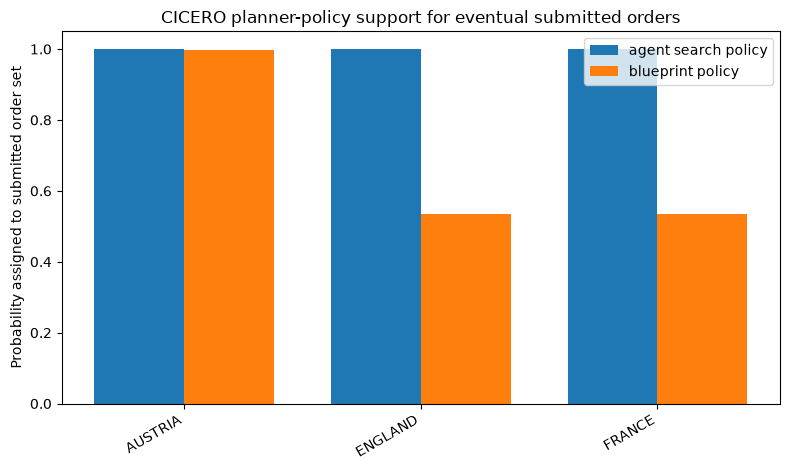

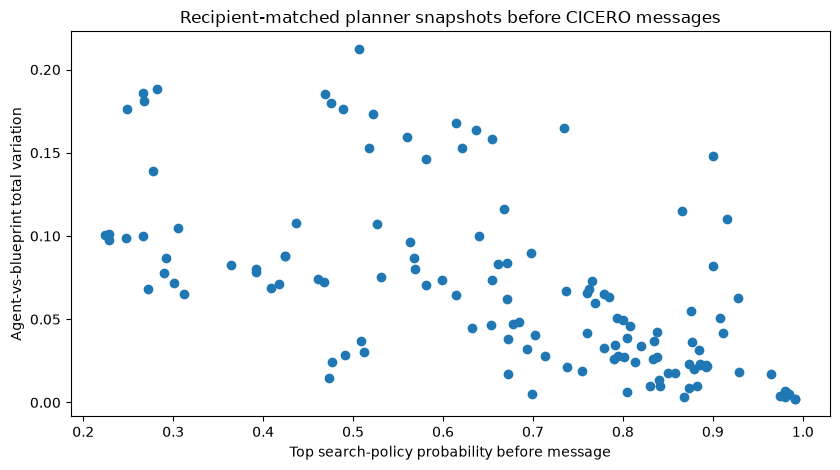

In [11]:
import matplotlib.pyplot as plt

if len(paired_orders):
    plot_df = paired_orders[["power", "agent_probability", "bp_probability"]].copy()
    x = np.arange(len(plot_df))
    width = 0.38
    fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 1.1), 4.8))
    ax.bar(x - width / 2, plot_df["agent_probability"], width, label="agent search policy")
    ax.bar(x + width / 2, plot_df["bp_probability"], width, label="blueprint policy")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["power"], rotation=30, ha="right")
    ax.set_ylabel("Probability assigned to submitted order set")
    ax.set_title("CICERO planner-policy support for eventual submitted orders")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "submitted_order_policy_probability.png", dpi=180)
    plt.show()

if len(message_df):
    exact = message_df[message_df["pairing_mode"] == "exact_sender_recipient_phase"].copy()
    if len(exact):
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        ax.scatter(exact["agent_top_probability"], exact["agent_bp_total_variation"])
        ax.set_xlabel("Top search-policy probability before message")
        ax.set_ylabel("Agent-vs-blueprint total variation")
        ax.set_title("Recipient-matched planner snapshots before CICERO messages")
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / "message_planner_snapshot_diagnostics.png", dpi=180)
        plt.show()


## 10. Readiness gate for the exact-input observer stage

Notebook 16 is ready to hand off only if:

- Notebook 15's accepted capture remains valid;
- Notebook 16 instrumentation loaded correctly;
- at least four messages pair exactly by sender+recipient+phase;
- those messages cover at least two recipients;
- at least three submitted order episodes are captured and have planner results available;
- the submitted order is on-support under the planner policy for at least 80% of paired order episodes;
- no instrumentation `_error` event occurred.

This gate validates the **mechanistic episode bank**, not H1.


In [12]:
readiness = {
    "frozen_cicero_commit": actual_commit_value == CICERO_COMMIT,
    "accepted_notebook15_handoff": all(nb15_readiness.get(k) is v for k, v in required_nb15.items()),
    "legacy_runtime_preflight_pass": preflight_probe["returncode"] == 0,
    "instrumentation_probe_pass": instrument_probe["returncode"] == 0,
    "capture_target_reached": bool(launch_result["capture_complete"]),
    "planner_results_present": len(planner_events) > 0,
    "message_exact_pair_count_at_least_4": int((message_df["pairing_mode"] == "exact_sender_recipient_phase").sum()) >= 4 if len(message_df) else False,
    "message_exact_pair_rate_at_least_0_8": message_pair_rate >= 0.8,
    "message_distinct_recipients_at_least_2": message_recipient_count >= 2,
    "order_episode_count_at_least_target": len(order_df) >= TARGET_ORDER_RESULTS,
    "order_planner_pair_rate_at_least_0_8": order_paired_rate >= 0.8,
    "order_agent_policy_support_rate_at_least_0_8": order_support_rate >= 0.8,
    "capture_error_events_absent": len(error_events) == 0,
}
readiness["ready_for_notebook17_exact_dialogue_observer"] = bool(all(readiness.values()))
(TABLE_DIR / "readiness.json").write_text(json.dumps(readiness, indent=2))
print(json.dumps(readiness, indent=2))

if STRICT_READINESS and not readiness["ready_for_notebook17_exact_dialogue_observer"]:
    raise RuntimeError(
        "Notebook 16 completed capture but failed one or more mechanistic readiness gates. "
        f"Inspect {TABLE_DIR / 'readiness.json'}, {TABLE_DIR / 'pairing_audit.json'}, and {TABLE_DIR / 'policy_fidelity_summary.json'}."
    )


{
  "frozen_cicero_commit": true,
  "accepted_notebook15_handoff": true,
  "legacy_runtime_preflight_pass": true,
  "instrumentation_probe_pass": true,
  "capture_target_reached": true,
  "planner_results_present": true,
  "message_exact_pair_count_at_least_4": true,
  "message_exact_pair_rate_at_least_0_8": true,
  "message_distinct_recipients_at_least_2": true,
  "order_episode_count_at_least_target": true,
  "order_planner_pair_rate_at_least_0_8": true,
  "order_agent_policy_support_rate_at_least_0_8": true,
  "capture_error_events_absent": false,
  "ready_for_notebook17_exact_dialogue_observer": false
}


RuntimeError: Notebook 16 completed capture but failed one or more mechanistic readiness gates. Inspect /workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/results/tables/readiness.json, /workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/results/tables/pairing_audit.json, and /workspace/latent-reservations/notebook_outputs/16_cicero_planner_intent_behavior_measurement/20260815T143203Z/results/tables/policy_fidelity_summary.json.

In [13]:
import json
import shutil

readiness_path = TABLE_DIR / "readiness.json"
pairing_path = TABLE_DIR / "pairing_audit.json"
launch_path = TABLE_DIR / "launch_result.json"

readiness = json.loads(readiness_path.read_text())
pairing = json.loads(pairing_path.read_text())
launch = json.loads(launch_path.read_text())

capture_errors = pairing.get("capture_error_events", [])

def is_keyboard_interrupt(event):
    payload = event.get("payload", {})
    text = (
        str(payload.get("error", ""))
        + "\n"
        + str(payload.get("traceback", ""))
    )
    return "KeyboardInterrupt" in text

expected_shutdown_interrupts = [
    e for e in capture_errors
    if is_keyboard_interrupt(e)
]

fatal_capture_errors = [
    e for e in capture_errors
    if not is_keyboard_interrupt(e)
]

# This salvage rule is deliberately narrow:
# - the capture target must already have completed;
# - every captured error must be KeyboardInterrupt;
# - every substantive v1 readiness gate must already have passed.
assert launch.get("capture_complete") is True
assert len(capture_errors) >= 1
assert len(fatal_capture_errors) == 0

core_keys = [
    "frozen_cicero_commit",
    "accepted_notebook15_handoff",
    "legacy_runtime_preflight_pass",
    "instrumentation_probe_pass",
    "capture_target_reached",
    "planner_results_present",
    "message_exact_pair_count_at_least_4",
    "message_exact_pair_rate_at_least_0_8",
    "message_distinct_recipients_at_least_2",
    "order_episode_count_at_least_target",
    "order_planner_pair_rate_at_least_0_8",
    "order_agent_policy_support_rate_at_least_0_8",
]

failed_core = [
    key for key in core_keys
    if readiness.get(key) is not True
]

assert not failed_core, failed_core

# Preserve the original v1 verdict.
backup_path = TABLE_DIR / "readiness_v1_original.json"
if not backup_path.exists():
    shutil.copy2(readiness_path, backup_path)

readiness["capture_error_events_absent"] = (
    len(capture_errors) == 0
)
readiness[
    "expected_post_capture_shutdown_interrupt_count"
] = len(expected_shutdown_interrupts)

readiness[
    "fatal_capture_error_events_absent"
] = len(fatal_capture_errors) == 0

readiness[
    "ready_for_notebook17_exact_dialogue_observer"
] = bool(
    all(readiness[key] is True for key in core_keys)
    and readiness["fatal_capture_error_events_absent"]
)

readiness["readiness_note"] = (
    "Notebook 16 v1 salvage: the only captured error(s) were "
    "KeyboardInterrupt events produced while intentionally stopping "
    "the CICERO process after the capture target had already been met. "
    "Raw error-free status is retained separately and remains false."
)

readiness_path.write_text(
    json.dumps(readiness, indent=2)
)

print(json.dumps(readiness, indent=2))

assert readiness[
    "ready_for_notebook17_exact_dialogue_observer"
]

{
  "frozen_cicero_commit": true,
  "accepted_notebook15_handoff": true,
  "legacy_runtime_preflight_pass": true,
  "instrumentation_probe_pass": true,
  "capture_target_reached": true,
  "planner_results_present": true,
  "message_exact_pair_count_at_least_4": true,
  "message_exact_pair_rate_at_least_0_8": true,
  "message_distinct_recipients_at_least_2": true,
  "order_episode_count_at_least_target": true,
  "order_planner_pair_rate_at_least_0_8": true,
  "order_agent_policy_support_rate_at_least_0_8": true,
  "capture_error_events_absent": false,
  "ready_for_notebook17_exact_dialogue_observer": true,
  "expected_post_capture_shutdown_interrupt_count": 1,
  "fatal_capture_error_events_absent": true,
  "readiness_note": "Notebook 16 v1 salvage: the only captured error(s) were KeyboardInterrupt events produced while intentionally stopping the CICERO process after the capture target had already been met. Raw error-free status is retained separately and remains false."
}


## 11. Freeze result summary and manifest

The resulting artifacts are enough for the next notebook to work from a frozen episode bank. The next stage should instrument the actual CICERO dialogue-model formatting/input boundary, construct a matched observer from **exactly that text**, and only then compare text-visible information against the internal planner reference.


In [14]:
def sha256_file(path):
    h = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "cicero_commit": CICERO_COMMIT,
    "source_notebook15_run_id": NB15_RUN_ID,
    "purpose": "Measure CICERO explicit planner-policy linkage to generated messages and submitted orders.",
    "scientific_status": (
        "Mechanistic planner-intent/outward-behavior measurement only; not activation-vs-text H1 and no steering claim."
    ),
    "claim_guardrail": (
        "Raw pydipcc Game serialization is audit/provenance only and is not treated as the matched dialogue-model text input."
    ),
    "launch_result": launch_result,
    "policy_fidelity": policy_fidelity_summary,
    "pairing_audit": pairing_audit,
    "readiness": readiness,
}
(TABLE_DIR / "result_summary.json").write_text(json.dumps(result_summary, indent=2))

artifact_paths = sorted(
    p for p in RUN_DIR.rglob("*")
    if p.is_file() and p.name != "checksums.json"
)
checksums = [
    {
        "relative_path": str(p.relative_to(RUN_DIR)),
        "sha256": sha256_file(p),
        "size_bytes": p.stat().st_size,
    }
    for p in artifact_paths
]
(RUN_DIR / "checksums.json").write_text(json.dumps(checksums, indent=2))

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_DIR),
    "source_notebook15_run": str(NB15_RUN_DIR),
    "instrumentation_source": str(SITE_CUSTOMIZE),
    "instrumentation_probe": str(RUNTIME_DIR / "instrumentation_probe.txt"),
    "full_agent_log": str(FULL_AGENT_LOG),
    "capture_event_directory": str(CAPTURE_DIR),
    "capture_events_merged": str(RUNTIME_DIR / "capture_events_merged.json"),
    "planner_message_episodes": str(TABLE_DIR / "planner_message_episodes.csv"),
    "planner_order_episodes": str(TABLE_DIR / "planner_order_episodes.csv"),
    "policy_fidelity_summary": str(TABLE_DIR / "policy_fidelity_summary.json"),
    "pairing_audit": str(TABLE_DIR / "pairing_audit.json"),
    "readiness": str(TABLE_DIR / "readiness.json"),
    "result_summary": str(TABLE_DIR / "result_summary.json"),
    "checksums": str(RUN_DIR / "checksums.json"),
    "figures": sorted(str(p) for p in FIGURE_DIR.glob("*.png")),
}
(MANIFEST_DIR / "notebook16_manifest.json").write_text(json.dumps(manifest, indent=2))

print(json.dumps(result_summary, indent=2))
print()
print("Notebook 16 complete.")
print("Result summary:", TABLE_DIR / "result_summary.json")
print("Run directory:", RUN_DIR)


{
  "notebook_build": "latent-reservations-notebook16-cicero-planner-intent-behavior-v1",
  "run_id": "20260815T143203Z",
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "source_notebook15_run_id": "20260815T140016Z",
  "purpose": "Measure CICERO explicit planner-policy linkage to generated messages and submitted orders.",
  "scientific_status": "Mechanistic planner-intent/outward-behavior measurement only; not activation-vs-text H1 and no steering claim.",
  "claim_guardrail": "Raw pydipcc Game serialization is audit/provenance only and is not treated as the matched dialogue-model text input.",
  "launch_result": {
    "command": [
      "/workspace/latent-reservations/.venvs/cicero_full_agent_py37_source_v5/bin/python",
      "run.py",
      "--adhoc",
      "--cfg",
      "conf/c01_ag_cmp/cmp.prototxt",
      "Iagent_one=agents/cicero.prototxt",
      "use_shared_agent=1",
      "power_one=TURKEY"
    ],
    "capture_complete": true,
    "process_exited_before_captu